# 09 Background Sequence Replay Detector Check

08 노트북은 field3 `val/test` 대표 샘플 32장으로 `field12_v1`과 `field3_v2`를 비교했다. 그런데 실제 주행에서는 한 장이 아니라 **연속 프레임**이 들어온다.

이번 노트북의 목적은 field1/field2에서 이미 수집해둔 background 주행 이미지를 시간순으로 재생하면서, 실제 Pi 카메라 스트림처럼 모델에 넣어보는 것이다.

핵심 질문은 하나다.

> 카메라 프레임이 계속 들어올 때, CLRKDNet detector가 노란선 후보를 계속 뽑고 있는가?

이 검증 결과를 이렇게 해석한다.

- lane 후보가 계속 살아있다: 모델 detector는 어느 정도 살아 있고, 다음 문제는 lane 선택/postprocess/control이다.
- lane 후보가 자주 0개가 된다: 모델 자체 또는 threshold가 아직 불안정하다.
- 후보는 뜨는데 3~4개씩 과하게 뜬다: detector postprocess pruning이 필요하다.
- 후보는 노란선 근처에 있는데 steering이 이상하다: driving postprocess 문제다.

## 1. 경로와 실행 설정

이 노트북은 로컬 VS Code의 `<env>` kernel 기준이다.

기본값은 field1/field2 background 전체 819장을 모두 사용한다. 너무 오래 걸리면 아래 값만 바꾸면 된다.

- `FRAME_STRIDE = 1`: 모든 프레임 사용. 빠르게 보고 싶으면 2, 3, 5로 변경.
- `MAX_FRAMES_PER_SEQUENCE = None`: 각 sequence 전체 사용. 빠른 smoke test는 60 정도로 변경.
- `SAVE_OVERLAY_EVERY = 1`: 모든 overlay 저장. 용량 줄이려면 2, 3, 5로 변경.

In [1]:
from pathlib import Path
import sys
import os
import re
import json
import pickle
import gc
import time
from dataclasses import dataclass

try:
    import cv2
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    try:
        from IPython.display import display, Video
    except Exception:
        display = print
        Video = None
except Exception as e:
    raise RuntimeError('이 노트북은 cv2, numpy, pandas, matplotlib이 필요함. <env> kernel을 확인해야 함.') from e

PROJECT_ROOT = Path(r'~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization')
EXP_ROOT = PROJECT_ROOT / '10_experiments' / '11_clrkdnet_precision_tuning'

FIELD1_BACKGROUND = PROJECT_ROOT / '10_experiments' / '02_field1_map_lab' / 'data' / '20260430_map_lab' / 'raw' / 'signs' / 'background'
FIELD2_BACKGROUND = PROJECT_ROOT / '10_experiments' / '04_field2_map_lab' / 'field2_experiment' / 'data' / '20260501_field2' / 'raw' / '07_traffic_capture' / 'background'

# 모델 구조는 이전 finetune_v1 Colab output의 code snapshot을 재사용한다.
V1_RUN = PROJECT_ROOT / '10_experiments' / '06_lane_model_finetuning' / 'colab_outputs' / 'finetune_v1' / 'MapLane_Field1Field2_full' / '20260505_201647_lr_1e-04_b_8'
CODE_DIR = V1_RUN / 'code'
V1_CONFIG = V1_RUN / 'config.py'
V1_CKPT = V1_RUN / 'ckpt' / 'best.pth'

V2_RUN = EXP_ROOT / 'colab_outputs' / 'field3_finetune_v2' / 'outputs' / 'MapLane_Field3_B_field12best_to_field3_full' / '20260507_205319_lr_5e-05_b_8'
V2_CONFIG = V2_RUN / 'config.py'
V2_CKPT = V2_RUN / 'ckpt' / 'best.pth'

# 08 노트북과 같은 detector 설정. 09는 sequence 안정성 확인이 목적이라 같은 기준으로 먼저 본다.
DETECTOR_CONF = 0.25
DETECTOR_NMS_THRES = 50
DETECTOR_MAX_LANES = 4

FRAME_STRIDE = 1
MAX_FRAMES_PER_SEQUENCE = None
SAVE_OVERLAY_EVERY = 1
VIDEO_FPS = 12
VIDEO_PANEL_WIDTH = 900
DISPLAY_VIDEO_IN_NOTEBOOK = True

REVIEW_ROOT = EXP_ROOT / 'review_outputs' / '09_background_sequence_replay_detector_check'
FRAME_DIR = REVIEW_ROOT / 'frames'
VIDEO_DIR = REVIEW_ROOT / 'videos'
PLOT_DIR = REVIEW_ROOT / 'plots'
CACHE_PATH = REVIEW_ROOT / 'sequence_prediction_cache.pkl'
FRAME_CSV = REVIEW_ROOT / 'sequence_frame_predictions.csv'
SUMMARY_CSV = REVIEW_ROOT / 'sequence_summary.csv'
SUMMARY_JSON = REVIEW_ROOT / 'sequence_replay_summary.json'

for d in [REVIEW_ROOT, FRAME_DIR, VIDEO_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)


def win_long_path(path):
    p = Path(path)
    s = str(p if p.is_absolute() else p.resolve())
    if os.name == 'nt' and not s.startswith('\\\\?\\'):
        return '\\\\?\\' + s
    return s


def path_exists(path):
    return Path(win_long_path(path)).exists()


def read_text_any(path, encoding='utf-8'):
    with open(win_long_path(path), 'r', encoding=encoding) as f:
        return f.read()


def cv2_imread_color(path):
    data = np.fromfile(win_long_path(path), dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, cv2.IMREAD_COLOR)


def cv2_imwrite(path, image_bgr):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    ok, buf = cv2.imencode(path.suffix or '.jpg', image_bgr)
    if not ok:
        raise RuntimeError(f'failed to encode image: {path}')
    Path(win_long_path(path)).write_bytes(buf.tobytes())

print('PROJECT_ROOT:', PROJECT_ROOT)
print('EXP_ROOT:', EXP_ROOT)
print('FIELD1_BACKGROUND:', FIELD1_BACKGROUND, 'exists=', path_exists(FIELD1_BACKGROUND))
print('FIELD2_BACKGROUND:', FIELD2_BACKGROUND, 'exists=', path_exists(FIELD2_BACKGROUND))
print('CODE_DIR:', CODE_DIR, 'exists=', path_exists(CODE_DIR))
print('V1_CKPT:', V1_CKPT, 'exists=', path_exists(V1_CKPT))
print('V2_CKPT:', V2_CKPT, 'exists=', path_exists(V2_CKPT))
print('REVIEW_ROOT:', REVIEW_ROOT)

for p in [FIELD1_BACKGROUND, FIELD2_BACKGROUND, CODE_DIR, V1_CONFIG, V1_CKPT, V2_CONFIG, V2_CKPT]:
    assert path_exists(p), p

PROJECT_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization
EXP_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning
FIELD1_BACKGROUND: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\02_field1_map_lab\data\20260430_map_lab\raw\signs\background exists= True
FIELD2_BACKGROUND: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\04_field2_map_lab\field2_experiment\data\20260501_field2\raw\07_traffic_capture\background exists= True
CODE_DIR: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8\code exists= True
V1_CKPT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8\ckpt\

## 2. background sequence 구성

파일명을 시간순으로 정렬한다. field1과 field2 모두 촬영 파일명이 시간/프레임 증가 순서를 포함하므로, 파일명 정렬이 곧 replay 순서에 가깝다.

In [2]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}
SEQUENCES = [
    {'sequence': 'field1_sign_background_drive', 'root': FIELD1_BACKGROUND},
    {'sequence': 'field2_traffic_background_drive', 'root': FIELD2_BACKGROUND},
]


def numeric_tail_key(path: Path):
    nums = re.findall(r'\d+', path.stem)
    return tuple(int(x) for x in nums[-4:]) if nums else (0,)


def list_sequence_images(root: Path):
    files = [p for p in root.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS and p.stat().st_size > 0]
    files = sorted(files, key=lambda p: (numeric_tail_key(p), p.name))
    if FRAME_STRIDE and FRAME_STRIDE > 1:
        files = files[::int(FRAME_STRIDE)]
    if MAX_FRAMES_PER_SEQUENCE is not None:
        files = files[:int(MAX_FRAMES_PER_SEQUENCE)]
    return files

sequence_rows = []
for seq in SEQUENCES:
    files = list_sequence_images(seq['root'])
    print(seq['sequence'], 'frames=', len(files), 'root=', seq['root'])
    if files:
        print('  first:', files[0].name)
        print('  last :', files[-1].name)
    for idx, path in enumerate(files):
        sequence_rows.append({
            'sequence': seq['sequence'],
            'frame_order': idx,
            'file_name': path.name,
            'path': str(path),
        })

sequence_df = pd.DataFrame(sequence_rows)
print('\ntotal replay frames:', len(sequence_df))
display(sequence_df.groupby('sequence').size().rename('frames').reset_index())
display(sequence_df.head())
assert len(sequence_df) > 0, 'no background frames found'

field1_sign_background_drive frames= 415 root= ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\02_field1_map_lab\data\20260430_map_lab\raw\signs\background
  first: 20260430_175024_signs_background_moving_mixed_right_0001.jpg
  last : 20260430_175156_signs_background_moving_mixed_right_0415.jpg
field2_traffic_background_drive frames= 319 root= ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\04_field2_map_lab\field2_experiment\data\20260501_field2\raw\07_traffic_capture\background
  first: 20260501_123424_07_traffic_capture_background_02853.jpg
  last : 20260501_123552_07_traffic_capture_background_04430.jpg

total replay frames: 734


,sequence,frames
0,field1_sign_background_drive,415
1,field2_traffic_background_drive,319


,sequence,frame_order,file_name,path
0,field1_sign_background_drive,0,20260430_175024_signs_background_moving_mixed_...,~\02_Projects\University\26-1_Em...
1,field1_sign_background_drive,1,20260430_175025_signs_background_moving_mixed_...,~\02_Projects\University\26-1_Em...
2,field1_sign_background_drive,2,20260430_175025_signs_background_moving_mixed_...,~\02_Projects\University\26-1_Em...
3,field1_sign_background_drive,3,20260430_175025_signs_background_moving_mixed_...,~\02_Projects\University\26-1_Em...
4,field1_sign_background_drive,4,20260430_175025_signs_background_moving_mixed_...,~\02_Projects\University\26-1_Em...


## 3. CLRKDNet 모델 로딩

08과 같은 방식이다.

- `field12_v1`: 1차+2차 pseudo dataset으로 학습한 이전 best
- `field3_v2`: field12 모델에서 field3 자동 라벨 데이터로 추가 학습한 이번 best

GT가 없는 background replay이므로, 여기서는 prediction lane count와 confidence, 그리고 영상 overlay를 본다.

In [3]:
try:
    import torch
except Exception as e:
    raise RuntimeError('torch가 없는 kernel임. <env> 또는 torch 설치 환경으로 실행해야 함.') from e

for module_name in list(sys.modules):
    if module_name == 'clrkd' or module_name.startswith('clrkd.') or module_name == 'mmcv' or module_name.startswith('mmcv.'):
        del sys.modules[module_name]

if str(CODE_DIR) in sys.path:
    sys.path.remove(str(CODE_DIR))
sys.path.insert(0, str(CODE_DIR))

from clrkd.utils.config import Config
import clrkd.models
from clrkd.models.registry import build_net

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('torch:', torch.__version__)
print('DEVICE:', DEVICE)


def load_config_windows_safe(config_path: Path):
    text = read_text_any(config_path)
    namespace = {}
    exec(compile(text, str(config_path), 'exec'), namespace)
    cfg_dict = {k: v for k, v in namespace.items() if not k.startswith('__')}
    cfg = Config(cfg_dict, cfg_text=text, filename=str(config_path))
    cfg.test_parameters.conf_threshold = float(DETECTOR_CONF)
    cfg.test_parameters.nms_thres = int(DETECTOR_NMS_THRES)
    cfg.test_parameters.nms_topk = int(DETECTOR_MAX_LANES)
    cfg.max_lanes = int(DETECTOR_MAX_LANES)
    return cfg


def torch_load(path: Path):
    try:
        return torch.load(win_long_path(path), map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(win_long_path(path), map_location=DEVICE)


def clean_state_dict(raw_state):
    cleaned = {}
    for key, value in raw_state.items():
        if key.startswith('module.'):
            key = key[len('module.'):]
        cleaned[key] = value
    return cleaned


def load_clrkd_model(model_name: str, config_path: Path, checkpoint_path: Path):
    cfg = load_config_windows_safe(config_path)
    model = build_net(cfg)
    ckpt = torch_load(checkpoint_path)
    raw_state = ckpt['net'] if isinstance(ckpt, dict) and 'net' in ckpt else ckpt
    state = clean_state_dict(raw_state)

    model_state = model.state_dict()
    compatible = {}
    skipped = []
    for key, value in state.items():
        if key in model_state and tuple(value.shape) == tuple(model_state[key].shape):
            compatible[key] = value
        else:
            skipped.append(key)

    missing, unexpected = model.load_state_dict(compatible, strict=False)
    model.to(DEVICE)
    model.eval()

    info = {
        'model_name': model_name,
        'config': str(config_path),
        'checkpoint': str(checkpoint_path),
        'loaded_tensors': len(compatible),
        'skipped_tensors': len(skipped),
        'missing_tensors': len(missing),
        'unexpected_tensors': len(unexpected),
    }
    return model, cfg, info


def preprocess_bgr_for_clrkd(img_bgr, cfg):
    crop = img_bgr[cfg.cut_height:, :, :]
    resized = cv2.resize(crop, (cfg.img_w, cfg.img_h), interpolation=cv2.INTER_CUBIC)
    tensor = resized.astype(np.float32) / 255.0
    tensor = torch.from_numpy(tensor).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    return tensor


def lane_to_serial(lane, cfg):
    pts = lane.to_array(cfg)
    if pts is None or len(pts) < 2:
        return None
    score = lane.metadata.get('conf', None)
    try:
        score = float(score.detach().cpu()) if hasattr(score, 'detach') else float(score)
    except Exception:
        score = None
    return {'points': pts.tolist(), 'score': score}


def predict_lanes_for_image(model, cfg, image_path: Path):
    img_bgr = cv2_imread_color(image_path)
    if img_bgr is None:
        raise RuntimeError(f'failed to read image: {image_path}')
    tensor = preprocess_bgr_for_clrkd(img_bgr, cfg)
    with torch.no_grad():
        output = model({'img': tensor})
        lanes = model.heads.get_lanes(output)[0]
    serial = []
    for lane in lanes:
        item = lane_to_serial(lane, cfg)
        if item is not None:
            serial.append(item)
    return serial

print('helpers ready')

torch: 2.11.0+cpu
DEVICE: cpu
helpers ready


## 4. sequence inference 실행

처음 실행은 시간이 걸릴 수 있다. 결과는 cache로 저장하므로, detector 설정이나 frame 설정을 바꾸지 않으면 다음 실행부터는 빠르게 열린다.

In [4]:
MODELS_TO_RUN = [
    ('field12_v1', V1_CONFIG, V1_CKPT),
    ('field3_v2', V2_CONFIG, V2_CKPT),
]

settings = {
    'sequences': [{'sequence': s['sequence'], 'root': str(s['root'])} for s in SEQUENCES],
    'frames': sequence_df[['sequence', 'frame_order', 'file_name', 'path']].to_dict(orient='records'),
    'models': [(name, str(cfg), str(ckpt)) for name, cfg, ckpt in MODELS_TO_RUN],
    'detector': {
        'conf': DETECTOR_CONF,
        'nms_thres': DETECTOR_NMS_THRES,
        'max_lanes': DETECTOR_MAX_LANES,
    },
    'frame_stride': FRAME_STRIDE,
    'max_frames_per_sequence': MAX_FRAMES_PER_SEQUENCE,
}


def run_or_load_sequence_predictions(force=False):
    if path_exists(CACHE_PATH) and not force:
        with open(win_long_path(CACHE_PATH), 'rb') as f:
            cache = pickle.load(f)
        if cache.get('settings') == settings:
            print('loaded cache:', CACHE_PATH)
            return cache
        print('cache exists but settings changed. rerun inference.')

    cache = {'settings': settings, 'frames': []}
    for _, row in sequence_df.iterrows():
        cache['frames'].append({
            'sequence': row['sequence'],
            'frame_order': int(row['frame_order']),
            'file_name': row['file_name'],
            'path': row['path'],
            'predictions': {},
        })

    total_frames = len(cache['frames'])
    for model_name, config_path, checkpoint_path in MODELS_TO_RUN:
        print(f'\nloading {model_name}: {checkpoint_path}')
        model, cfg, info = load_clrkd_model(model_name, config_path, checkpoint_path)
        print(info)
        start = time.time()
        for i, frame in enumerate(cache['frames']):
            pred = predict_lanes_for_image(model, cfg, Path(frame['path']))
            cache['frames'][i]['predictions'][model_name] = pred
            if i < 5 or (i + 1) % 50 == 0 or (i + 1) == total_frames:
                elapsed = time.time() - start
                fps = (i + 1) / elapsed if elapsed > 0 else 0
                print(f'{model_name:10s} {i+1:04d}/{total_frames} fps={fps:.2f} lanes={len(pred)} seq={frame["sequence"]} file={frame["file_name"]}')
        del model
        gc.collect()
        if DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

    with open(win_long_path(CACHE_PATH), 'wb') as f:
        pickle.dump(cache, f)
    print('\nsaved cache:', CACHE_PATH)
    return cache

cache = run_or_load_sequence_predictions(force=False)
print('cached frames:', len(cache['frames']))


loading field12_v1: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\06_lane_model_finetuning\colab_outputs\finetune_v1\MapLane_Field1Field2_full\20260505_201647_lr_1e-04_b_8\ckpt\best.pth
{'model_name': 'field12_v1', 'config': '~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\06_lane_model_finetuning\\colab_outputs\\finetune_v1\\MapLane_Field1Field2_full\\20260505_201647_lr_1e-04_b_8\\config.py', 'checkpoint': '~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\06_lane_model_finetuning\\colab_outputs\\finetune_v1\\MapLane_Field1Field2_full\\20260505_201647_lr_1e-04_b_8\\ckpt\\best.pth', 'loaded_tensors': 173, 'skipped_tensors': 0, 'missing_tensors': 0, 'unexpected_tensors': 0}
field12_v1 0001/734 fps=8.40 lanes=4 seq=field1_sign_background_drive file=20260430_175024_signs_background_moving_mixed_right_0001.jpg
field12_v1 0002/734 fps=8.88 lanes=4 seq=field1_sign_background_drive

## 5. 프레임별 통계 요약

GT가 없는 replay이므로, 여기서는 lane 개수와 confidence를 본다.

특히 중요한 값은 다음이다.

- `empty_frame_rate`: lane 후보가 하나도 안 나온 프레임 비율
- `mean_pred_count`: 평균 후보 개수
- `max_lanes_rate`: `DETECTOR_MAX_LANES`까지 꽉 차서 나온 프레임 비율. 이 값이 높으면 후보가 과다하다는 뜻이다.

In [5]:
frame_rows = []
for frame in cache['frames']:
    for model_name, preds in frame['predictions'].items():
        scores = [p.get('score') for p in preds if p.get('score') is not None]
        frame_rows.append({
            'sequence': frame['sequence'],
            'frame_order': frame['frame_order'],
            'file_name': frame['file_name'],
            'model': model_name,
            'pred_count': len(preds),
            'mean_conf': float(np.mean(scores)) if scores else np.nan,
            'max_conf': float(np.max(scores)) if scores else np.nan,
            'min_conf': float(np.min(scores)) if scores else np.nan,
            'scores': json.dumps([round(float(s), 4) for s in scores], ensure_ascii=False),
        })

frame_df = pd.DataFrame(frame_rows)
frame_df.to_csv(win_long_path(FRAME_CSV), index=False, encoding='utf-8-sig')
print('saved:', FRAME_CSV)

summary_rows = []
for (sequence, model), g in frame_df.groupby(['sequence', 'model']):
    pred = g['pred_count'].to_numpy()
    summary_rows.append({
        'sequence': sequence,
        'model': model,
        'frames': int(len(g)),
        'empty_frames': int((pred == 0).sum()),
        'empty_frame_rate': float((pred == 0).mean()),
        'mean_pred_count': float(np.mean(pred)),
        'median_pred_count': float(np.median(pred)),
        'max_lanes_frames': int((pred >= DETECTOR_MAX_LANES).sum()),
        'max_lanes_rate': float((pred >= DETECTOR_MAX_LANES).mean()),
        'mean_conf': float(g['mean_conf'].dropna().mean()) if g['mean_conf'].notna().any() else None,
        'median_conf': float(g['mean_conf'].dropna().median()) if g['mean_conf'].notna().any() else None,
    })
summary_df = pd.DataFrame(summary_rows).sort_values(['sequence', 'model']).reset_index(drop=True)
summary_df.to_csv(win_long_path(SUMMARY_CSV), index=False, encoding='utf-8-sig')
print('saved:', SUMMARY_CSV)
display(summary_df)

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\09_background_sequence_replay_detector_check\sequence_frame_predictions.csv
saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\09_background_sequence_replay_detector_check\sequence_summary.csv


,sequence,model,frames,empty_frames,empty_frame_rate,mean_pred_count,median_pred_count,max_lanes_frames,max_lanes_rate,mean_conf,median_conf
0,field1_sign_background_drive,field12_v1,415,4,0.009639,3.857831,4.0,389,0.937349,-0.001394,-0.056072
1,field1_sign_background_drive,field3_v2,415,2,0.004819,3.922892,4.0,400,0.963855,0.007708,-0.062051
2,field2_traffic_background_drive,field12_v1,319,9,0.028213,3.796238,4.0,295,0.924765,-0.021376,-0.059873
3,field2_traffic_background_drive,field3_v2,319,5,0.015674,3.877743,4.0,305,0.956113,0.009654,-0.055478


## 6. timeline plot

프레임이 진행될 때 prediction lane 개수가 계속 유지되는지 본다.  
만약 count가 자주 0으로 떨어지면 detector 자체가 불안정한 것이다. 반대로 거의 항상 4라면 후보가 과하게 살아있는 것이다.

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\09_background_sequence_replay_detector_check\plots\field1_sign_background_drive_timeline.png


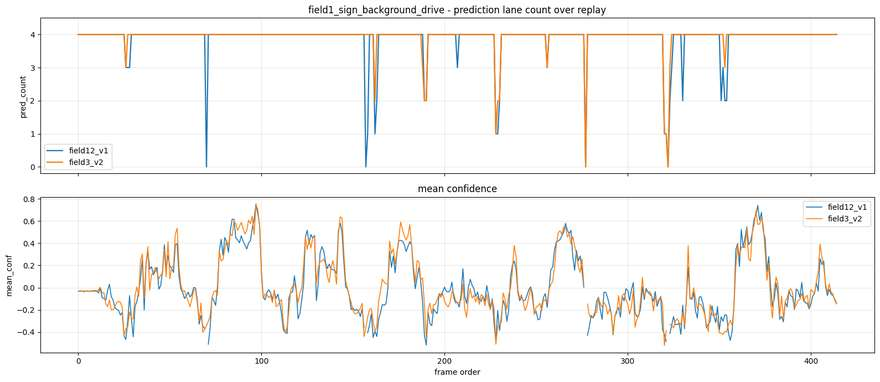

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\09_background_sequence_replay_detector_check\plots\field2_traffic_background_drive_timeline.png


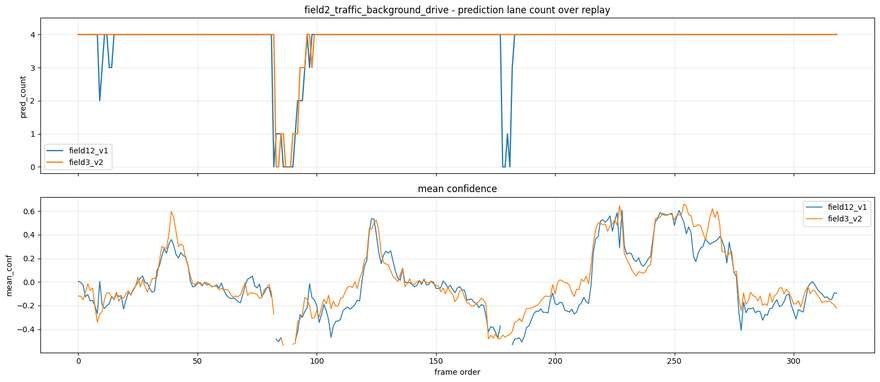

In [6]:
for sequence, gseq in frame_df.groupby('sequence'):
    fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
    for model, gm in gseq.groupby('model'):
        gm = gm.sort_values('frame_order')
        axes[0].plot(gm['frame_order'], gm['pred_count'], label=model, linewidth=1.6)
        axes[1].plot(gm['frame_order'], gm['mean_conf'], label=model, linewidth=1.2)
    axes[0].set_title(f'{sequence} - prediction lane count over replay')
    axes[0].set_ylabel('pred_count')
    axes[0].set_ylim(-0.2, DETECTOR_MAX_LANES + 0.5)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    axes[1].set_title('mean confidence')
    axes[1].set_xlabel('frame order')
    axes[1].set_ylabel('mean_conf')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    out_file = PLOT_DIR / f'{sequence}_timeline.png'
    fig.savefig(win_long_path(out_file), dpi=140, bbox_inches='tight')
    print('saved:', out_file)
    plt.show()

## 7. overlay frame과 mp4 생성

색상 의미는 08과 같다.

- 빨강: `field12_v1`
- 초록: `field3_v2`

영상은 raw panel과 combined panel을 나란히 저장한다. 이 영상을 보면 실제 카메라 스트림처럼 프레임이 넘어갈 때 라인 후보가 계속 살아있는지 빠르게 확인할 수 있다.

In [7]:
def draw_lane_list(img_bgr, lane_items, color_bgr, thickness=4, draw_score=False):
    out = img_bgr.copy()
    for lane in lane_items:
        pts = np.array(lane['points'], dtype=np.float32)
        if len(pts) < 2:
            continue
        pts_int = np.round(pts).astype(np.int32)
        cv2.polylines(out, [pts_int.reshape(-1, 1, 2)], isClosed=False, color=color_bgr, thickness=thickness, lineType=cv2.LINE_AA)
        if draw_score and lane.get('score') is not None:
            anchor = tuple(pts_int[min(len(pts_int) - 1, max(0, len(pts_int)//2))])
            cv2.putText(out, f'{lane["score"]:.2f}', anchor, cv2.FONT_HERSHEY_SIMPLEX, 0.55, color_bgr, 2, cv2.LINE_AA)
    return out


def resize_width(img, width):
    h, w = img.shape[:2]
    if w == width:
        return img
    scale = width / w
    return cv2.resize(img, (width, int(round(h * scale))), interpolation=cv2.INTER_AREA)


def make_replay_panel(frame):
    img_bgr = cv2_imread_color(frame['path'])
    if img_bgr is None:
        raise RuntimeError(frame['path'])
    raw = img_bgr.copy()
    combo = img_bgr.copy()
    v1 = frame['predictions'].get('field12_v1', [])
    v2 = frame['predictions'].get('field3_v2', [])
    combo = draw_lane_list(combo, v1, color_bgr=(40, 40, 255), thickness=3, draw_score=False)
    combo = draw_lane_list(combo, v2, color_bgr=(40, 230, 40), thickness=3, draw_score=False)

    label = f'{frame["sequence"]} #{frame["frame_order"]:04d} | v1={len(v1)} red | v2={len(v2)} green'
    cv2.putText(raw, label, (18, 34), cv2.FONT_HERSHEY_SIMPLEX, 0.85, (255, 255, 255), 3, cv2.LINE_AA)
    cv2.putText(raw, label, (18, 34), cv2.FONT_HERSHEY_SIMPLEX, 0.85, (20, 20, 20), 1, cv2.LINE_AA)
    raw_small = resize_width(raw, VIDEO_PANEL_WIDTH)
    combo_small = resize_width(combo, VIDEO_PANEL_WIDTH)
    h = min(raw_small.shape[0], combo_small.shape[0])
    raw_small = raw_small[:h]
    combo_small = combo_small[:h]
    return np.hstack([raw_small, combo_small])

video_paths = []
for sequence in sequence_df['sequence'].unique():
    seq_frames = [f for f in cache['frames'] if f['sequence'] == sequence]
    seq_dir = FRAME_DIR / sequence
    seq_dir.mkdir(parents=True, exist_ok=True)
    video_path = VIDEO_DIR / f'{sequence}_v1_red_v2_green.mp4'

    first_panel = make_replay_panel(seq_frames[0])
    h, w = first_panel.shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(str(video_path), fourcc, VIDEO_FPS, (w, h))
    assert writer.isOpened(), f'failed to open video writer: {video_path}'

    for i, frame in enumerate(seq_frames):
        panel = make_replay_panel(frame)
        if panel.shape[:2] != (h, w):
            panel = cv2.resize(panel, (w, h), interpolation=cv2.INTER_AREA)
        writer.write(panel)
        if SAVE_OVERLAY_EVERY and (i % int(SAVE_OVERLAY_EVERY) == 0):
            out_file = seq_dir / f'{i:05d}_{Path(frame["file_name"]).stem}.jpg'
            cv2_imwrite(out_file, panel)
        if i < 5 or (i + 1) % 100 == 0 or (i + 1) == len(seq_frames):
            print(f'{sequence} overlay {i+1:04d}/{len(seq_frames)}')
    writer.release()
    video_paths.append(video_path)
    print('saved video:', video_path)

print('videos:')
for p in video_paths:
    print(' -', p)

field1_sign_background_drive overlay 0001/415
field1_sign_background_drive overlay 0002/415
field1_sign_background_drive overlay 0003/415
field1_sign_background_drive overlay 0004/415
field1_sign_background_drive overlay 0005/415
field1_sign_background_drive overlay 0100/415
field1_sign_background_drive overlay 0200/415
field1_sign_background_drive overlay 0300/415
field1_sign_background_drive overlay 0400/415
field1_sign_background_drive overlay 0415/415
saved video: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\09_background_sequence_replay_detector_check\videos\field1_sign_background_drive_v1_red_v2_green.mp4
field2_traffic_background_drive overlay 0001/319
field2_traffic_background_drive overlay 0002/319
field2_traffic_background_drive overlay 0003/319
field2_traffic_background_drive overlay 0004/319
field2_traffic_background_drive overlay 0005/319
field2_traffic_background_drive overlay 0100/319
field2

## 8. 영상 재생

아래 셀은 노트북 안에서 mp4를 바로 보여준다.  
만약 VS Code에서 재생이 무겁거나 안 뜨면, `review_outputs/09.../videos` 폴더의 mp4를 직접 열면 된다.

In [8]:
if DISPLAY_VIDEO_IN_NOTEBOOK and Video is not None:
    for p in video_paths:
        print(p)
        display(Video(str(p), embed=False, html_attributes='controls loop'))
else:
    print('Video display skipped. Open files manually:')
    for p in video_paths:
        print(p)

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\09_background_sequence_replay_detector_check\videos\field1_sign_background_drive_v1_red_v2_green.mp4


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\09_background_sequence_replay_detector_check\videos\field2_traffic_background_drive_v1_red_v2_green.mp4


## 9. 실행 결과 저장

다음 판단 기준으로 읽으면 된다.

- `empty_frame_rate`가 낮다: detector가 프레임마다 뭔가를 계속 내고 있음.
- `max_lanes_rate`가 높다: detector가 후보를 너무 많이 뿌리는 경향이 있음.
- 영상에서 초록선이 노란선 근처에 계속 붙어 있다: field3 v2는 detector로 살릴 가능성이 있음.
- 영상에서 초록선이 사라지거나 엉뚱한 곳으로 자주 튄다: 추가 데이터/라벨/학습전략을 다시 봐야 함.

In [9]:
result_summary = {
    'notebook': '09_background_sequence_replay_detector_check',
    'sequences': [{'sequence': s['sequence'], 'root': str(s['root'])} for s in SEQUENCES],
    'models': {
        'field12_v1': str(V1_CKPT),
        'field3_v2': str(V2_CKPT),
    },
    'detector': {
        'conf': DETECTOR_CONF,
        'nms_thres': DETECTOR_NMS_THRES,
        'max_lanes': DETECTOR_MAX_LANES,
    },
    'frame_stride': FRAME_STRIDE,
    'max_frames_per_sequence': MAX_FRAMES_PER_SEQUENCE,
    'total_replay_frames': int(len(sequence_df)),
    'summary': summary_df.to_dict(orient='records'),
    'frame_csv': str(FRAME_CSV),
    'summary_csv': str(SUMMARY_CSV),
    'video_paths': [str(p) for p in video_paths],
    'frame_dir': str(FRAME_DIR),
    'plot_dir': str(PLOT_DIR),
}
SUMMARY_JSON.write_text(json.dumps(result_summary, ensure_ascii=False, indent=2), encoding='utf-8')
print('saved:', SUMMARY_JSON)
display(summary_df)

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\11_clrkdnet_precision_tuning\review_outputs\09_background_sequence_replay_detector_check\sequence_replay_summary.json


,sequence,model,frames,empty_frames,empty_frame_rate,mean_pred_count,median_pred_count,max_lanes_frames,max_lanes_rate,mean_conf,median_conf
0,field1_sign_background_drive,field12_v1,415,4,0.009639,3.857831,4.0,389,0.937349,-0.001394,-0.056072
1,field1_sign_background_drive,field3_v2,415,2,0.004819,3.922892,4.0,400,0.963855,0.007708,-0.062051
2,field2_traffic_background_drive,field12_v1,319,9,0.028213,3.796238,4.0,295,0.924765,-0.021376,-0.059873
3,field2_traffic_background_drive,field3_v2,319,5,0.015674,3.877743,4.0,305,0.956113,0.009654,-0.055478


## 10. 실행 후 메모

이 셀은 실행 결과를 보고 직접 적는 공간이다.

확인할 것:

- field1 sequence에서 초록선이 계속 살아있는가?
- field2 sequence에서 초록선이 계속 살아있는가?
- 빨강(v1)과 초록(v2) 중 어느 쪽이 노란선 근처에 더 안정적인가?
- count가 계속 4로 꽉 차면, 다음 10 노트북은 `conf/nms/max_lanes` sequence sweep으로 넘어간다.